# Rasters in 3-D — real DEMs from every angle

This notebook takes **real raster data** read through pyramids and renders it as 3-D relief with `Scene3D.terrain`, then looks at it under the conditions that matter for terrain: **different camera angles**, **vertical exaggeration**, **orthographic vs perspective** projection, and a **point-cloud drape**. Data: `LisbonElevation.tif` (real elevation, EPSG:4326).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import geopandas as gpd

pv.OFF_SCREEN = True  # headless: scenes render to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title='', view='iso', parallel=False, zoom=None):
    """Point the camera at a named view, then screenshot the scene inline (asserts it isn't blank).

    view: 'iso' (oblique), 'top' (map/plan view), 'front', 'side', or an (azimuth, elevation) offset tuple
    applied on top of the isometric view. parallel=True uses an orthographic camera (true map scale).
    """
    p = scene.plotter
    if parallel:
        p.enable_parallel_projection()
    if view == 'top':
        p.view_xy()
    elif view == 'front':
        p.view_xz()
    elif view == 'side':
        p.view_yz()
    elif isinstance(view, tuple):
        p.view_isometric(); p.camera.azimuth += view[0]; p.camera.elevation += view[1]
    else:
        p.view_isometric()
    if zoom:
        p.camera.zoom(zoom)
    p.render()
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def lines_to_tubes(gdf, radius, z=0.0):
    """Turn a (Multi)LineString GeoDataFrame into a single tube mesh at height z (only coords read)."""
    tubes = []
    for geom in gdf.geometry:
        for part in (geom.geoms if geom.geom_type.startswith('Multi') else [geom]):
            xy = np.asarray(part.coords, dtype='float64')
            if len(xy) < 2:
                continue
            pts = np.column_stack([xy[:, 0], xy[:, 1], np.full(len(xy), z)])
            tubes.append(pv.lines_from_points(pts).tube(radius=radius))
    return pv.MultiBlock(tubes).combine()

def lollipops(gdf, value_col, height, radius):
    """Build vertical stems (a tube mesh) + top points (xyz, values) for a 3-D lollipop chart of point data."""
    x = gdf.geometry.x.to_numpy(); y = gdf.geometry.y.to_numpy()
    v = gdf[value_col].to_numpy(dtype='float64')
    z = v / np.nanmax(v) * height
    stems = [pv.Line((xi, yi, 0.0), (xi, yi, zi)).tube(radius=radius) for xi, yi, zi in zip(x, y, z)]
    return pv.MultiBlock(stems).combine(), np.column_stack([x, y, z]), v


2026-06-11 22:27:25 | INFO | pyramids.base.config | Logging is configured.


## The DEM, from four camera angles

One scene, four viewpoints — an oblique isometric, a top-down **plan/map view**, a low-angle oblique, and a rotated azimuth. The camera is moved between shots; the mesh is built once.

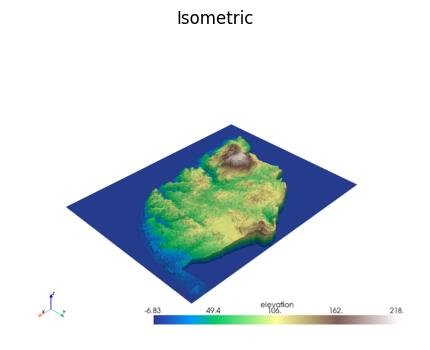

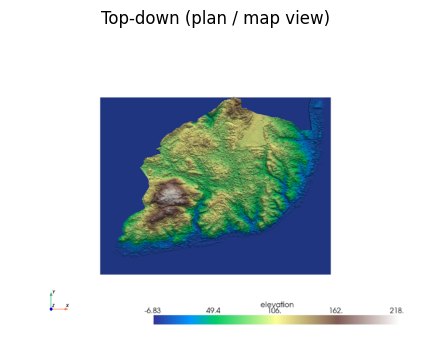

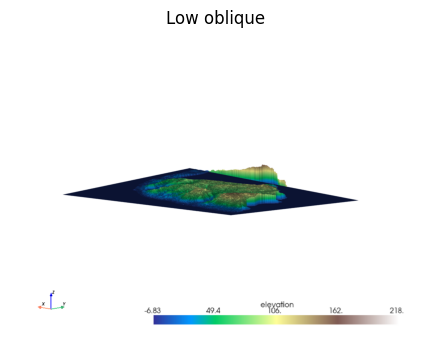

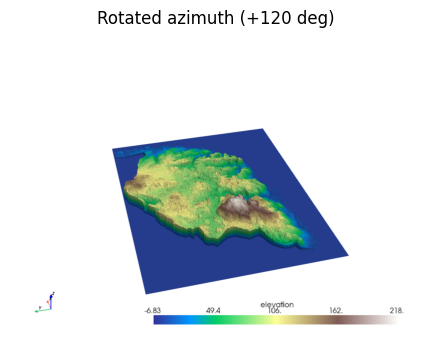

In [2]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')
scene.plotter.add_axes()
show(scene, 'Isometric', view='iso')
show(scene, 'Top-down (plan / map view)', view='top')
show(scene, 'Low oblique', view=(0, -45))
show(scene, 'Rotated azimuth (+120 deg)', view=(120, 0))
scene.close()

## Vertical exaggeration — a condition, not the data

Relief is the same DEM; exaggeration only changes how readable it is. `1.0` is geometrically faithful, higher values accentuate subtle terrain.

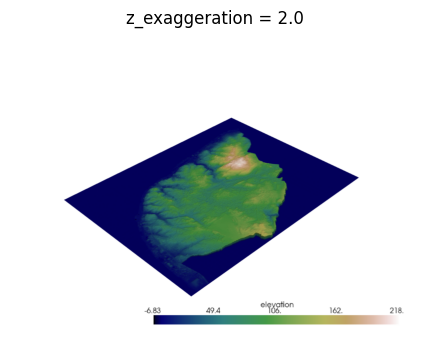

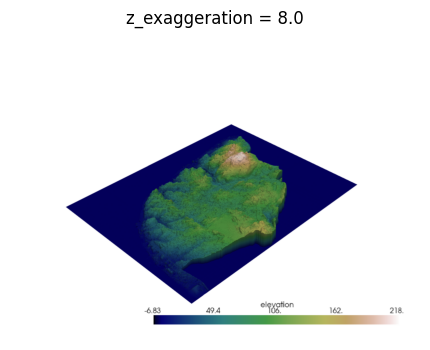

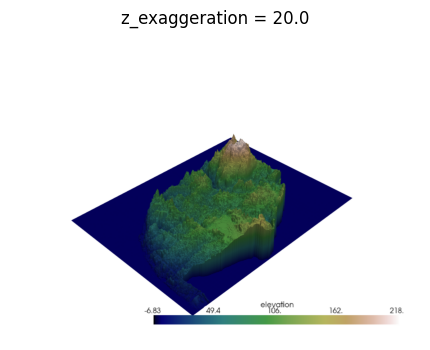

In [3]:
for zexag in (2.0, 8.0, 20.0):
    scene = Scene3D(off_screen=True)
    scene.terrain(dem, z_exaggeration=zexag, cmap='gist_earth')
    show(scene, f'z_exaggeration = {zexag}', view='iso')
    scene.close()

## Orthographic vs perspective

Perspective (default) gives depth cues; an **orthographic** (parallel) camera preserves true scale across the scene — the convention for plan-accurate maps.

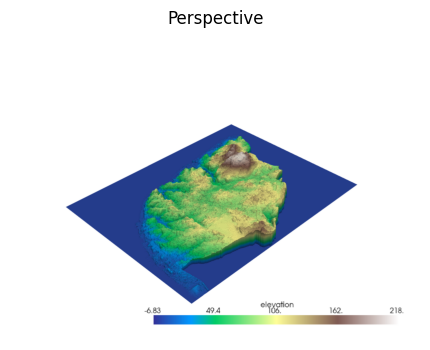

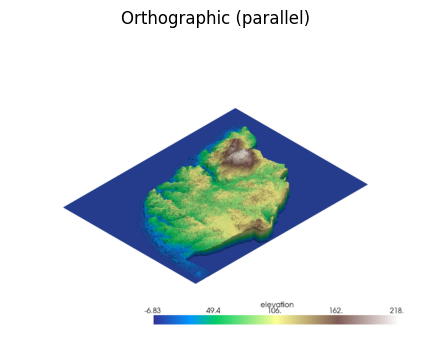

In [4]:
for parallel, label in [(False, 'Perspective'), (True, 'Orthographic (parallel)')]:
    scene = Scene3D(off_screen=True)
    scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')
    show(scene, label, view='iso', parallel=parallel)
    scene.close()

## The same raster as a point cloud

Sampling the DEM to an xyz table and rendering it with `point_cloud` (eye-dome lighting) is an alternative to a warped surface — useful for LiDAR-style data. x/y are degrees and z is metres, so z is scaled into degree-equivalent units (the convention `terrain` applies internally).

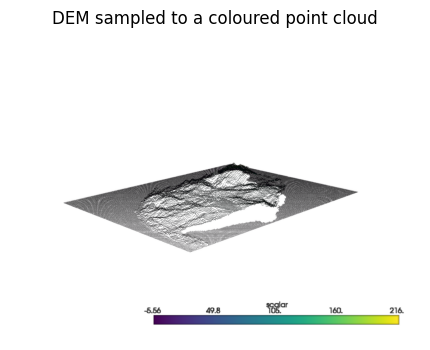

In [5]:
arr = dem.read_array()[::3, ::3]
xx, yy = np.meshgrid(dem.x[::3], dem.y[::3])
finite = np.isfinite(arr.ravel())
elev = arr.ravel()[finite]
pts = np.column_stack([xx.ravel()[finite], yy.ravel()[finite], elev / 111_320.0 * 8.0])
scene = Scene3D(off_screen=True)
scene.point_cloud(pts, values=elev, point_size=3.0, cmap='viridis')
show(scene, 'DEM sampled to a coloured point cloud', view=(0, -20))
scene.close()